# Spaceship Titanic: End-to-End Tabular Classification Pipeline Design

## Portfolio case study

This project uses Kaggle's **Spaceship Titanic** competition as a practical case study in building a clean tabular classification workflow. The goal is to predict whether a passenger was **Transported** to an alternate dimension using demographic, travel, cabin, and onboard spending information.

The main focus is not only the final competition score. The real portfolio value is showing how a machine learning engineer thinks through an end-to-end classification problem: data contracts, exploratory analysis, feature extraction, preprocessing pipelines, model comparison, validation, and final submission generation.

---

## Why this project matters after Titanic

The original Titanic competition is useful for learning the basics of classification. Spaceship Titanic is a stronger second project because it allows a cleaner demonstration of engineering maturity:

- A more structured preprocessing pipeline.
- Feature extraction from compound columns such as `PassengerId` and `Cabin`.
- Separation between numerical, low-cardinality categorical, and high-cardinality features.
- Reusable transformations for both training and test data.
- Multiple model comparisons instead of depending on one algorithm.
- A portfolio-friendly story around tabular ML pipeline design.

In other words, this notebook is positioned as an **end-to-end tabular classification pipeline**, not just another Kaggle notebook.


## 1. Problem framing

The task is a binary classification problem:

> Given passenger information from the Spaceship Titanic dataset, predict whether each passenger was transported to another dimension.

### Target variable

- `Transported`: whether the passenger was transported.

### Main input groups

- Passenger identity and group information: `PassengerId`, `Name`
- Travel details: `HomePlanet`, `Destination`, `Cabin`
- Passenger status: `CryoSleep`, `VIP`, `Age`
- Onboard spending: `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`

### Portfolio framing

A strong tabular ML system is not only about choosing XGBoost, LightGBM, or CatBoost. The more important engineering question is:

> Can the same preprocessing and feature logic be applied consistently from training data to unseen test data?

This notebook is designed around that question.


## 2. Architecture and data contracts

Before modeling, the notebook defines a small configuration layer. This keeps important project-level information in one place instead of scattering file paths and column names across the notebook.

This is a simple version of a **data contract**:

- where the data lives,
- which columns are expected as features,
- which column is the target,
- where outputs should be saved.

For a Kaggle notebook, this may look small. For a real ML project, this habit matters because it makes the workflow easier to debug, reproduce, and convert into a proper repository later.


In [3]:
"""Global Configuration Block"""

import pandas as pd
import numpy as np
import os


BASE_DIRECTORY = os.path.join('./')
DATA_DIRECTORY = os.path.join(BASE_DIRECTORY, '/content/dataset')
TRAIN_FILE = os.path.join(DATA_DIRECTORY, '/content/dataset/train.csv')
OUTPUT_DIR = os.path.join(BASE_DIRECTORY, '/content/output')

FEATURES = ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name']
TARGET = 'Transported'

## 3. Exploratory data analysis and logic mapping

The first EDA pass checks the basic shape of the data, missing values, column types, and summary statistics. The goal is not to create many random plots. The goal is to understand which columns require cleaning and which columns contain useful signals for feature engineering.

The notebook focuses especially on:

- missing values,
- boolean columns such as `CryoSleep`, `VIP`, and `Transported`,
- spending behavior,
- relationships between passenger state and the target variable.

This phase creates the logic that later becomes preprocessing and feature engineering.


In [4]:
df = pd.read_csv(TRAIN_FILE)
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [5]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


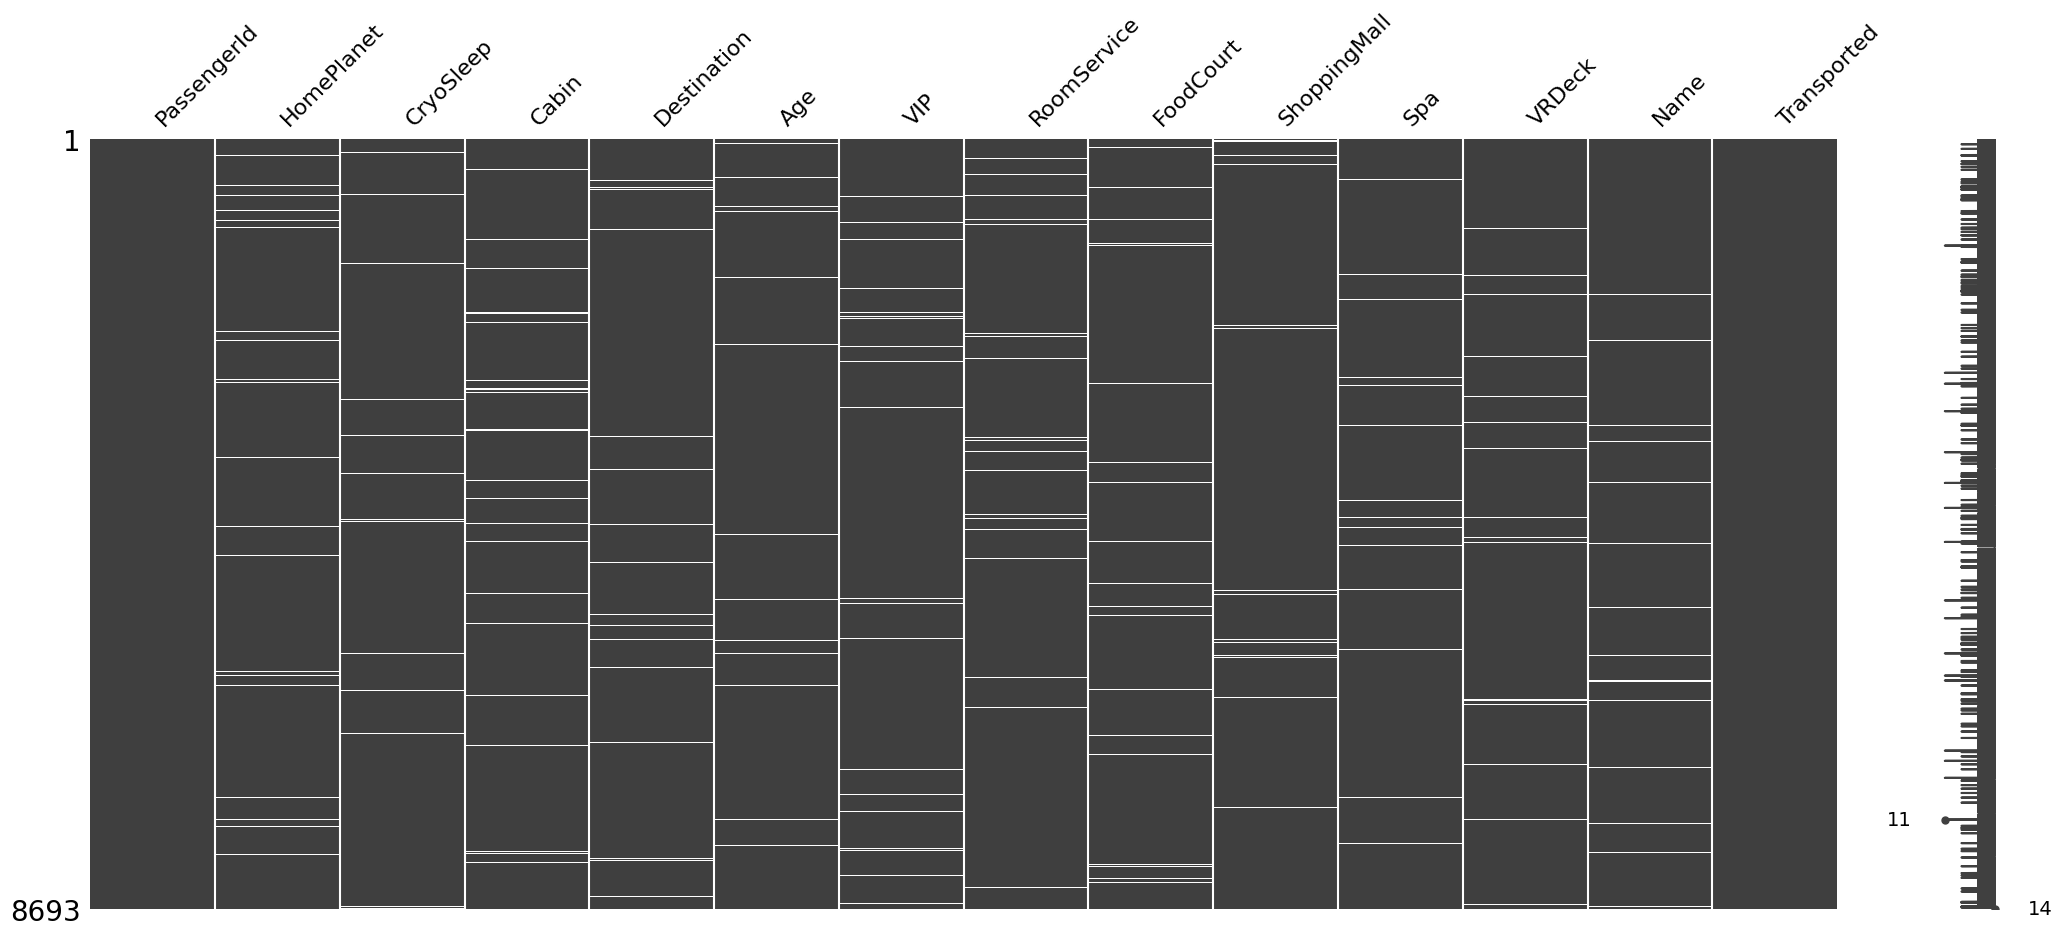

In [8]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [9]:
df['Transported'] = df['Transported'].map({True: 1, False: 0})
df['Transported']

,Transported
0,0
1,1
2,0
3,0
4,1
...,...
8688,0
8689,0
8690,1
8691,0


In [10]:
df['CryoSleep'] = df['CryoSleep'].map({True: 1, False: 0})
df['CryoSleep']

,CryoSleep
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
8688,0.0
8689,1.0
8690,0.0
8691,0.0


### 3.1 Core predictor analysis

After converting boolean values into numerical format, the notebook checks whether specific variables have strong relationship with the target.

The most important early hypothesis is:

> Passengers in CryoSleep may behave differently from active passengers, especially in spending-related columns.

This is useful because feature engineering should be driven by dataset behavior, not by guessing.


In [11]:
df['Transported'] = df['Transported'].fillna(0).astype(int)
correlation = df.corr(numeric_only= True)['Transported']
correlation

,Transported
CryoSleep,0.468645
Age,-0.075026
RoomService,-0.244611
FoodCourt,0.046566
ShoppingMall,0.010141
Spa,-0.221131
VRDeck,-0.207075
Transported,1.000000


In [12]:
# Fill NaN with 0, then convert to regular int
df['CryoSleep'] = df['CryoSleep'].fillna(0).astype(int)

print(df[['CryoSleep', 'Transported']].corr())

             CryoSleep  Transported
CryoSleep     1.000000     0.460132
Transported   0.460132     1.000000


### Key finding: CryoSleep is a strong signal

The analysis suggests that `CryoSleep` is one of the most important behavioral indicators in the dataset. Passengers in CryoSleep have a very different spending pattern and appear more likely to be transported.

This matters because it gives the model a meaningful structure to learn from. Instead of treating every feature independently, the notebook uses domain logic such as:

- CryoSleep passengers should usually have no onboard spending.
- Spending behavior can become a signal of passenger activity.
- Passenger grouping and cabin location can add extra context.


In [13]:
(df['CryoSleep'] ==  1).sum() / (df['Transported'] ==  1).sum()

np.float64(0.6936957514846962)

In [14]:
df['VIP'] = df['VIP'].map({True: 1, False: 0})
df['VIP'] = df['VIP'].fillna(0).astype(int)

In [15]:
# Of those in CryoSleep, what percentage were Transported?
cryo_transport_rate = df[df['CryoSleep'] == 1]['Transported'].mean()
print(f"{cryo_transport_rate:.2%}")


81.76%


The observed CryoSleep transport rate is roughly **81–82%** in this analysis. That does not mean CryoSleep alone solves the problem, but it clearly deserves special attention in the feature engineering phase.


### 3.2 Spending behavior analysis

The spending columns are not just raw numerical values. They describe passenger behavior during the trip.

The notebook studies spending across:

- `RoomService`
- `FoodCourt`
- `ShoppingMall`
- `Spa`
- `VRDeck`

This creates the motivation for building aggregate spending features later. In real tabular ML work, these domain-inspired aggregates often improve signal more than blindly trying larger models.


In [16]:
df[df['CryoSleep'] == 1]['ShoppingMall'].sum()

np.float64(0.0)

In [17]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in spending_cols:
    cryo_spending = df[df['CryoSleep'] == 1][col].sum()
    non_cryo_spending = df[df['CryoSleep'] == 0][col].sum()
    print(f"{col}: CryoSleep=${cryo_spending:,.0f} | Non-CryoSleep=${non_cryo_spending:,.0f}")

RoomService: CryoSleep=$0 | Non-CryoSleep=$1,912,541
FoodCourt: CryoSleep=$0 | Non-CryoSleep=$3,898,237
ShoppingMall: CryoSleep=$0 | Non-CryoSleep=$1,474,092
Spa: CryoSleep=$0 | Non-CryoSleep=$2,647,791
VRDeck: CryoSleep=$0 | Non-CryoSleep=$2,592,790


In [18]:
# Check if ANY CryoSleep passenger has non-zero spending
for col in spending_cols:
    cryo_with_spending = df[(df['CryoSleep'] == 1) & (df[col] > 0)][col].count()
    print(f"{col}: {cryo_with_spending} CryoSleep passengers with spending")

RoomService: 0 CryoSleep passengers with spending
FoodCourt: 0 CryoSleep passengers with spending
ShoppingMall: 0 CryoSleep passengers with spending
Spa: 0 CryoSleep passengers with spending
VRDeck: 0 CryoSleep passengers with spending


In [19]:
# Full breakdown
df.groupby('CryoSleep')[spending_cols].describe()

RoomService                                                         \
                count        mean         std  min  25%  50%    75%      max   
CryoSleep                                                                      
0              5543.0  345.037164  800.697994  0.0  0.0  2.0  380.5  14327.0   
1              2969.0    0.000000    0.000000  0.0  0.0  0.0    0.0      0.0   

          FoodCourt              ...    Spa           VRDeck              \
              count        mean  ...    75%      max   count        mean   
CryoSleep                        ...                                       
0            5543.0  703.272055  ...  336.5  22408.0  5530.0  468.858951   
1            2967.0    0.000000  ...    0.0      0.0  2975.0    0.000000   

                                                       
                   std  min  25%  50%    75%      max  
CryoSleep                                              
0          1393.581343  0.0  0.0  3.0  340.0  24133.0  
1             0.000000  0.0  0.0  0.0    0.0      0.0  

[2 rows x 40 columns]

## 4. Feature engineering: turning raw columns into model-ready signals

This is the most important part of the notebook from a portfolio perspective.

Several raw columns contain hidden structure:

- `Cabin` contains deck, cabin number, and side.
- `PassengerId` contains group identity and passenger position inside the group.
- Spending columns can be aggregated into behavioral features.
- Group size can reveal whether someone traveled alone or with others.

This section turns raw Kaggle columns into reusable model features. This is close to **feature-store style thinking**: create meaningful derived features once, then reuse them consistently for training and submission.


### 4.1 String decomposition features

The notebook extracts structured information from string columns:

- `Cabin` → `Deck`, `CabinNum`, `Side`
- `PassengerId` → `GroupId`, `GroupPos`
- `GroupId` → `GroupSize`

This is a common tabular ML pattern: one raw column may contain multiple useful features if it is parsed correctly.


In [20]:
# Extract Cabin components
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)

# Extract PassengerId components
df[['GroupId', 'GroupPos']] = df['PassengerId'].str.split('_', expand=True)

# Calculate Group Size
df['GroupSize'] = df.groupby('GroupId')['GroupId'].transform('count')

In [21]:
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')
df['GroupPos'] = pd.to_numeric(df['GroupPos'], errors='coerce')

In [22]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['total_spending'] = df[spending_cols].sum(axis=1, skipna = False)
df['total_spending']

,total_spending
0,0.0
1,736.0
2,10383.0
3,5176.0
4,1091.0
...,...
8688,8536.0
8689,0.0
8690,1873.0
8691,4637.0


In [23]:
x = df['GroupSize']
df['is_solo'] = x.apply(lambda x: 0 if x > 1 else 1)

In [24]:
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,Deck,CabinNum,Side,GroupId,GroupPos,GroupSize,total_spending,is_solo
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,...,Maham Ofracculy,0,B,0.0,P,0001,1,1,0.0,1
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,...,Juanna Vines,1,F,0.0,S,0002,1,1,736.0,1
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,...,Altark Susent,0,A,0.0,S,0003,1,2,10383.0,0
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,...,Solam Susent,0,A,0.0,S,0003,2,2,5176.0,0
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,...,Willy Santantines,1,F,1.0,S,0004,1,1,1091.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,...,Gravior Noxnuther,0,A,98.0,P,9276,1,1,8536.0,1
8689,9278_01,Earth,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,...,Kurta Mondalley,0,G,1499.0,S,9278,1,1,0.0,1
8690,9279_01,Earth,0,G/1500/S,TRAPPIST-1e,26.0,0,0.0,0.0,1872.0,...,Fayey Connon,1,G,1500.0,S,9279,1,1,1873.0,1
8691,9280_01,Europa,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,...,Celeon Hontichre,0,E,608.0,S,9280,1,2,4637.0,0


In [25]:
df['total_spending'].isnull().sum()

np.int64(908)

In [26]:
df['has_spending'] = (df['total_spending'] > 0).astype(int)

In [27]:
df['total_spending'] = np.where((df['CryoSleep'] == 1) | (df['Age'] < 13), 0, 1)
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Transported,Deck,CabinNum,Side,GroupId,GroupPos,GroupSize,total_spending,is_solo,has_spending
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,...,0,B,0.0,P,0001,1,1,1,1,0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,...,1,F,0.0,S,0002,1,1,1,1,1
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,...,0,A,0.0,S,0003,1,2,1,0,1
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,...,0,A,0.0,S,0003,2,2,1,0,1
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,...,1,F,1.0,S,0004,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,...,0,A,98.0,P,9276,1,1,1,1,1
8689,9278_01,Earth,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,...,0,G,1499.0,S,9278,1,1,0,1,0
8690,9279_01,Earth,0,G/1500/S,TRAPPIST-1e,26.0,0,0.0,0.0,1872.0,...,1,G,1500.0,S,9279,1,1,1,1,1
8691,9280_01,Europa,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,...,0,E,608.0,S,9280,1,2,1,0,1


## 5. Scikit-learn preprocessing pipeline

The notebook separates features by how they should be processed:

### Numerical features

These are imputed with the median and scaled:

- `Age`
- spending columns
- `total_spending`
- `GroupSize`
- `CabinNum`

### Low-cardinality categorical features

These are imputed with the most frequent value and one-hot encoded:

- `HomePlanet`
- `Destination`
- `CryoSleep`
- `VIP`
- `Deck`
- `Side`
- `is_solo`
- `has_spending`

### High-cardinality categorical features

These are dropped or handled indirectly because direct one-hot encoding would create too many sparse columns:

- `PassengerId`
- `Cabin`
- `Name`
- `GroupId`
- `GroupPos`

This design decision keeps the pipeline simple, stable, and easy to explain.


In [28]:
# Numerical features (continuous/discrete numbers)
numerical_features = [
    'Age',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'total_spending',
    'GroupSize',
    'CabinNum'
]

# Low cardinality categoricals (few unique values - use OneHotEncoder)
low_cardinality_cats = [
    'HomePlanet',    # Earth, Europa, Mars
    'Destination',   # TRAPPIST-1e, PSO J318.5-22, 55 Cancri e
    'CryoSleep',     # binary
    'VIP',           # binary
    'Deck',          # extracted from Cabin
    'Side',          # Port/Starboard
    'is_solo' ,       # binary (1 if traveling alone)
    'has_spending'  #   spending flag
]

# High cardinality categoricals (need special handling - target encode or drop)
high_cardinality_cats = [
    'PassengerId',   # too many unique values
    'Cabin',         # too many unique values (already split into Deck/CabinNum/Side)
    'Name',          # too many unique values
    'GroupId',      # too many unique values
    'GroupPos'      # too many unique values
]

### 5.1 Numerical transformer

The numerical pipeline handles missing values first and then scales the features. This protects the model from raw missing values and keeps numeric ranges more controlled.


In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

### 5.2 Categorical transformer

The categorical pipeline fills missing categories and applies one-hot encoding. `handle_unknown='ignore'` is important because the test set may contain categories not seen during training.

This is one of the small but important production-style choices in the notebook.


In [30]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output= False))])

In [31]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, low_cardinality_cats)], remainder='drop')

In [32]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_estimators= 200))
])

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Transported'])
y = df['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

In [33]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (6085, 22)
Test shape:  (2608, 22)


In [34]:
# Train model
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

## 6. Modeling and validation

The notebook starts with a baseline-style pipeline using a `RandomForestClassifier`, then evaluates performance with validation metrics and cross-validation.

This creates a reference point before trying stronger gradient boosting models.

The modeling section compares:

- Random Forest
- XGBoost
- LightGBM with Optuna tuning
- CatBoost

This comparison is useful because the portfolio story becomes stronger: the final model is selected after experimentation, not chosen randomly.


In [35]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Validation Score: {accuracy_score(y_pred, y_test):.4f}")
print(f'\nClassification report: {classification_report(y_pred, y_test)}')

Validation Score: 0.7941

Classification report:               precision    recall  f1-score   support

           0       0.85      0.76      0.80      1438
           1       0.74      0.83      0.78      1170

    accuracy                           0.79      2608
   macro avg       0.79      0.80      0.79      2608
weighted avg       0.80      0.79      0.79      2608



In [36]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipeline, X, y, cv=5)
print(f"Mean: {scores.mean():.2f}, Std: {scores.std():.2f}")

Mean: 0.79, Std: 0.03


In [37]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
lst_accu_stratified = []

for train_index, test_index in skf.split(X, y):
	x_train_fold, x_test_fold = X.iloc[train_index], X.iloc[test_index]
	y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
	pipeline.fit(x_train_fold, y_train_fold)
	lst_accu_stratified.append(pipeline.score(x_test_fold, y_test_fold))

In [38]:
print(lst_accu_stratified)
print(max(lst_accu_stratified))

[0.7965517241379311, 0.7977011494252874, 0.7977011494252874, 0.810126582278481, 0.7917146144994246, 0.8296892980437284, 0.8227848101265823, 0.7951668584579977, 0.7859608745684695, 0.7917146144994246]
0.8296892980437284


### 6.1 XGBoost experiment

XGBoost cannot directly consume raw object/string columns in the same way as the scikit-learn pipeline. So the notebook first uses the fitted preprocessing pipeline to transform the data into numeric model-ready features.

This is a good engineering detail: preprocessing stays consistent, while the model can be swapped.


XGBoost cannot handle object (string) columns directly. Unlike the sklearn pipeline which handles preprocessing internally, XGBoost needs numeric data.

So we need to use the pipeline's preprocessor to transform the data first:

In [39]:
from xgboost import XGBClassifier

# Transform data using the preprocessor first (XGBoost can't handle object columns)
X_transformed = pipeline.named_steps['preprocessor'].transform(X)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

model = XGBClassifier()
model.fit(X_transformed, y)

y_pred = model.predict(X_test_transformed)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9179447852760736


In [40]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}

# Create XGBClassifier WITHOUT passing param_grid (that goes to GridSearchCV)
xgb_model = XGBClassifier()

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1)

grid_search.fit(X_transformed, y)

print("Best parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Best Accuracy: 0.7902971232623804


### 6.2 LightGBM with Optuna tuning

LightGBM is tested with hyperparameter optimization using Optuna. Instead of manually guessing parameters, the notebook defines a search space and lets Optuna explore stronger configurations.

This demonstrates a more mature model selection workflow:

1. Define a validation strategy.
2. Define a search space.
3. Optimize the metric.
4. Compare the result against other models.


In [42]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.6 MB/s eta 0:00:00


In [43]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):
    # Search space
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': 0.05
    }

    # Train and Evaluate
    clf = lgb.LGBMClassifier(**params, n_estimators=1000, verbose=-1)
    # Using cross-validation to get stable score
    score = cross_val_score(clf, X_transformed, y, cv=5, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Increased trials for better results
print('Best params:', study.best_params)
print('Best accuracy:', study.best_value)


[I 2026-04-28 17:24:47,308] A new study created in memory with name: no-name-f5f0ea71-829c-4992-a6d4-c91ac321f10d
/tmp/ipykernel_13107/1731178147.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
/tmp/ipykernel_13107/1731178147.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
/tmp/ipykernel_13107/1731178147.py:13: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'feature_fraction': trial.suggest_unif

Best params: {'lambda_l1': 9.93491266600391, 'lambda_l2': 8.65679082530127e-08, 'num_leaves': 100, 'feature_fraction': 0.8891833128267418, 'bagging_fraction': 0.7628659681864571, 'bagging_freq': 6, 'min_child_samples': 63}
Best accuracy: 0.7884570514250019


### 6.3 CatBoost final candidate

CatBoost is tested as another strong gradient boosting model. In this run, CatBoost becomes the best-performing candidate in the notebook's validation setup.

The notebook reports:

- **CatBoost accuracy:** 0.8719
- **LightGBM Optuna best accuracy:** 0.7885

Because CatBoost performed best here, it is used for the final submission predictions.


In [44]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [45]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize CatBoostClassifier
cat_model = CatBoostClassifier(random_state=42, verbose=0) # verbose=0 to suppress training output

# Train the model
cat_model.fit(X_transformed, y)

# Make predictions on the transformed test set
y_pred_cat = cat_model.predict(X_test_transformed)

# Evaluate the model
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nCatBoost Classification Report:\n", classification_report(y_test, y_pred_cat))

CatBoost Accuracy: 0.8719325153374233

CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      1295
           1       0.86      0.88      0.87      1313

    accuracy                           0.87      2608
   macro avg       0.87      0.87      0.87      2608
weighted avg       0.87      0.87      0.87      2608



## 7. Model selection summary

Based on the notebook's validation results, CatBoost is selected as the final model for submission generation.

The important portfolio takeaway is not only that CatBoost performed well. The stronger takeaway is that the workflow supports model replacement:

- preprocessing is reusable,
- transformed features can be passed into different estimators,
- validation metrics can compare models fairly,
- the final model can be selected based on evidence.


In [46]:
y_pred_best_model = cat_model.predict(X_test_transformed)
print("First 5 predictions from the best model (CatBoost):")
print(y_pred_best_model[:5])

First 5 predictions from the best model (CatBoost):
[0 0 0 1 1]


## 8. Final submission pipeline

The final section applies the same feature engineering logic to the test data, transforms the test data using the fitted preprocessor, generates predictions with the selected CatBoost model, and saves a Kaggle-ready `submission.csv` file.

This is an important part of the case study because many beginner notebooks train a model but fail to show a clean inference/submission flow.

A complete classification project should show both:

- training-time workflow,
- inference-time workflow.


In [47]:
# Define the path to the test file
TEST_FILE = os.path.join(DATA_DIRECTORY, 'test.csv')

# Load the test dataset
df_test = pd.read_csv(TEST_FILE)
display(df_test.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [48]:
# Apply the same feature engineering steps to the test data

# Handle CryoSleep and VIP columns (map and fillna as done for training)
df_test['CryoSleep'] = df_test['CryoSleep'].map({True: 1, False: 0})
df_test['CryoSleep'] = df_test['CryoSleep'].fillna(0).astype(int)
df_test['VIP'] = df_test['VIP'].map({True: 1, False: 0})
df_test['VIP'] = df_test['VIP'].fillna(0).astype(int)

# Extract Cabin components
df_test[['Deck', 'CabinNum', 'Side']] = df_test['Cabin'].str.split('/', expand=True)

# Extract PassengerId components
df_test[['GroupId', 'GroupPos']] = df_test['PassengerId'].str.split('_', expand=True)

# Calculate Group Size
df_test['GroupSize'] = df_test.groupby('GroupId')['GroupId'].transform('count')

# Convert CabinNum and GroupPos to numeric
df_test['CabinNum'] = pd.to_numeric(df_test['CabinNum'], errors='coerce')
df_test['GroupPos'] = pd.to_numeric(df_test['GroupPos'], errors='coerce')

# Calculate total spending
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_test['total_spending'] = df_test[spending_cols].sum(axis=1, skipna=False)

# Create 'is_solo' feature
df_test['is_solo'] = df_test['GroupSize'].apply(lambda x: 0 if x > 1 else 1)

# Create 'has_spending' feature
df_test['has_spending'] = (df_test['total_spending'] > 0).astype(int)

# Reassign total_spending based on CryoSleep or Age (as done for training)
df_test['total_spending'] = np.where((df_test['CryoSleep'] == 1) | (df_test['Age'] < 13), 0, 1)

display(df_test.head())

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Deck,CabinNum,Side,GroupId,GroupPos,GroupSize,total_spending,is_solo,has_spending
0,0013_01,Earth,1,G/3/S,TRAPPIST-1e,27.0,0,0.0,0.0,0.0,...,Nelly Carsoning,G,3.0,S,0013,1,1,0,1,0
1,0018_01,Earth,0,F/4/S,TRAPPIST-1e,19.0,0,0.0,9.0,0.0,...,Lerome Peckers,F,4.0,S,0018,1,1,1,1,1
2,0019_01,Europa,1,C/0/S,55 Cancri e,31.0,0,0.0,0.0,0.0,...,Sabih Unhearfus,C,0.0,S,0019,1,1,0,1,0
3,0021_01,Europa,0,C/1/S,TRAPPIST-1e,38.0,0,0.0,6652.0,0.0,...,Meratz Caltilter,C,1.0,S,0021,1,1,1,1,1
4,0023_01,Earth,0,F/5/S,TRAPPIST-1e,20.0,0,10.0,0.0,635.0,...,Brence Harperez,F,5.0,S,0023,1,1,1,1,1


In [49]:
# Transform the test data using the fitted preprocessor
X_submission_transformed = pipeline.named_steps['preprocessor'].transform(df_test)

# Make predictions using the best CatBoost model
submission_predictions = cat_model.predict(X_submission_transformed)

# Create the submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Transported': submission_predictions.astype(bool) # Convert 0/1 to False/True
})

display(submission_df.head())

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [50]:
# Save the submission file
submission_output_path = os.path.join(OUTPUT_DIR, 'submission.csv')
submission_df.to_csv(submission_output_path, index=False)

print(f"Submission file created successfully at: {submission_output_path}")

Submission file created successfully at: /content/output/submission.csv


## 9. Case study conclusion

This project demonstrates a complete tabular classification workflow using the Spaceship Titanic dataset.

The strongest parts of the work are:

- structured project configuration,
- EDA connected to feature engineering decisions,
- extraction of useful features from `Cabin` and `PassengerId`,
- clean separation of numerical and categorical preprocessing,
- reusable scikit-learn pipeline design,
- model comparison across Random Forest, XGBoost, LightGBM, and CatBoost,
- final Kaggle submission generation.

## What I would improve next

If this project were converted into a production-style ML repository, the next improvements would be:

1. Move repeated feature engineering logic into a reusable function or transformer class.
2. Save the fitted preprocessor and model using `joblib`.
3. Add a `src/` folder with separate files for preprocessing, training, evaluation, and inference.
4. Track experiments with MLflow or a simple CSV experiment log.
5. Add feature importance or SHAP-based explainability.
6. Add a clear `README.md` with problem framing, pipeline diagram, results, and lessons learned.
7. Add unit tests for feature engineering functions such as cabin parsing and group-size extraction.

## Portfolio positioning

A good title for this project would be:

> **Spaceship Titanic: End-to-End Tabular Classification Pipeline Design**

This makes the project sound like an engineering case study rather than a basic Kaggle submission.

The project shows progression from the original Titanic workflow into a cleaner second classification project with better preprocessing, stronger pipeline thinking, and more realistic model comparison.
